<a href="https://colab.research.google.com/github/harshad333-v/Jupyter_NoteBook/blob/main/Stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Stock Market Forecasting using SARIMA

## Project Overview

### Objective
The objective of this project is to develop a **Seasonal AutoRegressive Integrated Moving Average (SARIMA)** model to forecast the **next trading day's Open Price** of Apple Inc. (AAPL) stock using historical market data obtained from Yahoo Finance.

### Problem Statement
Stock prices form a time series where observations are recorded sequentially over time. Forecasting future stock prices is a challenging task because financial markets are dynamic, nonlinear, and influenced by numerous external factors.

This project focuses on applying the SARIMA model, a classical statistical forecasting technique, to model historical stock prices and predict the next day's opening price.

### Dataset
- **Source:** Yahoo Finance
- **Stock:** Apple Inc. (AAPL)
- **Target Variable:** Open Price

### Development Environment
- Python
- Jupyter Notebook

### Libraries
- pandas
- numpy
- matplotlib
- seaborn
- yfinance
- statsmodels
- scikit-learn

### Project Workflow

1. Import Libraries
2. Data Collection
3. Data Inspection
4. Data Cleaning
5. Exploratory Data Analysis
6. Time Series Analysis
7. Stationarity Testing
8. Differencing
9. ACF & PACF Analysis
10. Train-Test Split
11. SARIMA Model Building
12. Residual Diagnostics
13. Forecasting
14. Model Evaluation
15. Conclusion

---

# Step 1 : Import Required Libraries

## Objective

Import all the required Python libraries for data collection, visualization, statistical analysis, model development, and evaluation.

## Why is this step required?

Different libraries perform different tasks throughout the project.

- **Pandas** → Data manipulation
- **NumPy** → Numerical computations
- **Matplotlib & Seaborn** → Data visualization
- **Yahoo Finance** → Download historical stock data
- **Statsmodels** → Time series analysis and SARIMA implementation
- **Scikit-learn** → Model evaluation metrics

Properly organizing imports improves readability and maintainability of the notebook.

In [ ]:
# ==========================================================
# Step 1 : Import Required Libraries
# ==========================================================

# ----------------------------
# Data Manipulation
# ----------------------------
import pandas as pd
import numpy as np

# ----------------------------
# Data Visualization
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Stock Market Data
# ----------------------------
import yfinance as yf
from plotly.graph_objs.layout.shape import label

# ----------------------------
# Time Series Analysis
# ----------------------------
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ----------------------------
# Model Evaluation
# ----------------------------
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# ----------------------------
# Utility
# ----------------------------
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# Visualization Settings
# ----------------------------
plt.style.use("seaborn-v0_8")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (14, 6)

plt.rcParams["font.size"] = 12

# ----------------------------
# Display Settings
# ----------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", "{:.4f}".format)

print("=" * 60)
print("All libraries imported successfully.")
print("=" * 60)

All libraries imported successfully.


# Step 2 : Data Collection

## Objective

Download historical stock price data for Apple Inc. (AAPL) from Yahoo Finance.

## Why is this step required?

Machine learning and time series forecasting models require historical observations to learn patterns over time.

Yahoo Finance provides reliable historical stock market data, including:

- Open Price
- High Price
- Low Price
- Close Price
- Volume

This dataset will serve as the foundation for the entire forecasting project.

## Dataset Information

**Stock Symbol:** AAPL

**Source:** Yahoo Finance

**Frequency:** Daily

**Time Period:** 2010-01-01 to Present

The downloaded data contains OHLCV information:

- Open
- High
- Low
- Close
- Volume

In [ ]:
# ==========================================================
# Step 2 : Download Historical Stock Data
# ==========================================================

# Stock ticker
ticker = "AAPL"

# Download historical data
df = yf.download(ticker,start="2010-01-01",end=None,interval="1d",auto_adjust=False,progress=False)

# Display first five rows
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2010-01-04,6.4065,7.6432,7.6607,7.5850,7.6225,493729600
2010-01-05,6.4176,7.6564,7.6996,7.6161,7.6643,601904800
2010-01-06,6.3155,7.5346,7.6868,7.5268,7.6564,552160000
2010-01-07,6.3038,7.5207,7.5714,7.4661,7.5625,477131200
2010-01-08,6.3457,7.5707,7.5714,7.4664,7.5107,447610800


In [ ]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2026-06-24,293.0800,293.0800,299.7000,292.9400,295.3600,53081900
2026-06-25,275.1500,275.1500,288.8000,273.7500,287.4000,107013700
2026-06-26,283.7800,283.7800,285.9500,274.2100,275.0000,261775500
2026-06-29,281.7400,281.7400,288.3700,279.8500,286.7300,66427000
2026-06-30,289.3600,289.3600,289.9400,280.7000,281.1700,65043800


In [ ]:
# Dataset dimensions

df.shape

(4147, 6)

In [ ]:
print("Columns in Dataset")

for column in df.columns:
    print(column)

Columns in Dataset
('Adj Close', 'AAPL')
('Close', 'AAPL')
('High', 'AAPL')
('Low', 'AAPL')
('Open', 'AAPL')
('Volume', 'AAPL')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4147 entries, 2010-01-04 to 2026-06-30
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  4147 non-null   float64
 1   (Close, AAPL)      4147 non-null   float64
 2   (High, AAPL)       4147 non-null   float64
 3   (Low, AAPL)        4147 non-null   float64
 4   (Open, AAPL)       4147 non-null   float64
 5   (Volume, AAPL)     4147 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 226.8 KB


In [ ]:
df.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Adj Close,AAPL,4147.0000,83.1703,80.9641,5.7491,18.5917,40.4564,147.4823,315.2000
Close,AAPL,4147.0000,85.5910,80.6403,6.8589,21.9289,42.9250,150.4550,315.2000
High,AAPL,4147.0000,86.4493,81.4552,7.0000,22.1450,43.2750,151.5700,317.4000
Low,AAPL,4147.0000,84.6665,79.7754,6.7946,21.6523,42.5750,148.5600,309.6500
Open,AAPL,4147.0000,85.5280,80.5725,6.8704,21.9914,42.9500,149.9800,314.1800
Volume,AAPL,4147.0000,214004706.1490,214222638.5825,17910600.0000,74787600.0000,127111600.0000,282506000.0000,1880998000.0000


# Step 3 : Data Validation & Quality Assessment

## Objective

Validate the quality of the downloaded dataset before performing exploratory data analysis and model building.

## Why is this step required?

A forecasting model is only as good as the data used to train it.

Before performing any statistical analysis, we must verify that the dataset is:

- Complete
- Consistent
- Free from duplicate records
- Properly indexed by date
- Suitable for time series forecasting

Ignoring data quality issues can lead to incorrect analysis and unreliable model performance.

## Validation Checklist

- Dataset Shape
- Missing Values
- Duplicate Records
- Data Types
- Date Index
- Missing Trading Days
- Invalid Values

In [ ]:
# Check Negative Values

numeric_columns = ["Open", "High", "Low", "Close", "Volume"]

for col in numeric_columns:
    negative = (df[col] < 0).sum()
    print(f"{col:<10}: {negative}")

Open      : Ticker
AAPL    0
dtype: int64
High      : Ticker
AAPL    0
dtype: int64
Low       : Ticker
AAPL    0
dtype: int64
Close     : Ticker
AAPL    0
dtype: int64
Volume    : Ticker
AAPL    0
dtype: int64


In [ ]:
# Validation Summary

print("=" * 60)
print("DATA VALIDATION SUMMARY")
print("=" * 60)

print(f"Missing Values      : {df.isnull().sum().sum()}")
print(f"Duplicate Records   : {df.duplicated().sum()}")
print(f"Chronological Order : {df.index.is_monotonic_increasing}")
print(f"Date Range          : {df.index.min().date()} to {df.index.max().date()}")

print("\nDataset validation completed successfully.")

DATA VALIDATION SUMMARY
Missing Values      : 0
Duplicate Records   : 0
Chronological Order : True
Date Range          : 2010-01-04 to 2026-06-30

Dataset validation completed successfully.


# Step 4 : Exploratory Data Analysis (EDA)

## Objective

Explore the historical stock data to understand its characteristics before applying the SARIMA model.

## Why is this step required?

Exploratory Data Analysis (EDA) helps identify important patterns such as:

- Long-term trends
- Price volatility
- Distribution of observations
- Relationships between variables
- Potential seasonality
- Data anomalies

Understanding these characteristics is essential before performing stationarity tests and building a forecasting model.

## Analysis Performed

- Dataset Overview
- Open Price Trend
- Distribution of Open Price
- Trading Volume Analysis
- Correlation Analysis
- Rolling Mean and Rolling Standard Deviation

In [ ]:
# ==========================================================
# Step 4.1 : Dataset Overview
# ==========================================================

display(df.head())

display(df.tail())

print(df.describe().T)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2010-01-04,6.4065,7.6432,7.6607,7.5850,7.6225,493729600
2010-01-05,6.4176,7.6564,7.6996,7.6161,7.6643,601904800
2010-01-06,6.3155,7.5346,7.6868,7.5268,7.6564,552160000
2010-01-07,6.3038,7.5207,7.5714,7.4661,7.5625,477131200
2010-01-08,6.3457,7.5707,7.5714,7.4664,7.5107,447610800


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2026-06-24,293.0800,293.0800,299.7000,292.9400,295.3600,53081900
2026-06-25,275.1500,275.1500,288.8000,273.7500,287.4000,107013700
2026-06-26,283.7800,283.7800,285.9500,274.2100,275.0000,261775500
2026-06-29,281.7400,281.7400,288.3700,279.8500,286.7300,66427000
2026-06-30,289.3600,289.3600,289.9400,280.7000,281.1700,65043800


                     count           mean            std           min           25%            50%            75%             max
Price     Ticker                                                                                                                  
Adj Close AAPL   4147.0000        83.1703        80.9641        5.7491       18.5917        40.4564       147.4823        315.2000
Close     AAPL   4147.0000        85.5910        80.6403        6.8589       21.9289        42.9250       150.4550        315.2000
High      AAPL   4147.0000        86.4493        81.4552        7.0000       22.1450        43.2750       151.5700        317.4000
Low       AAPL   4147.0000        84.6665        79.7754        6.7946       21.6523        42.5750       148.5600        309.6500
Open      AAPL   4147.0000        85.5280        80.5725        6.8704       21.9914        42.9500       149.9800        314.1800
Volume    AAPL   4147.0000 214004706.1490 214222638.5825 17910600.0000 74787600.000

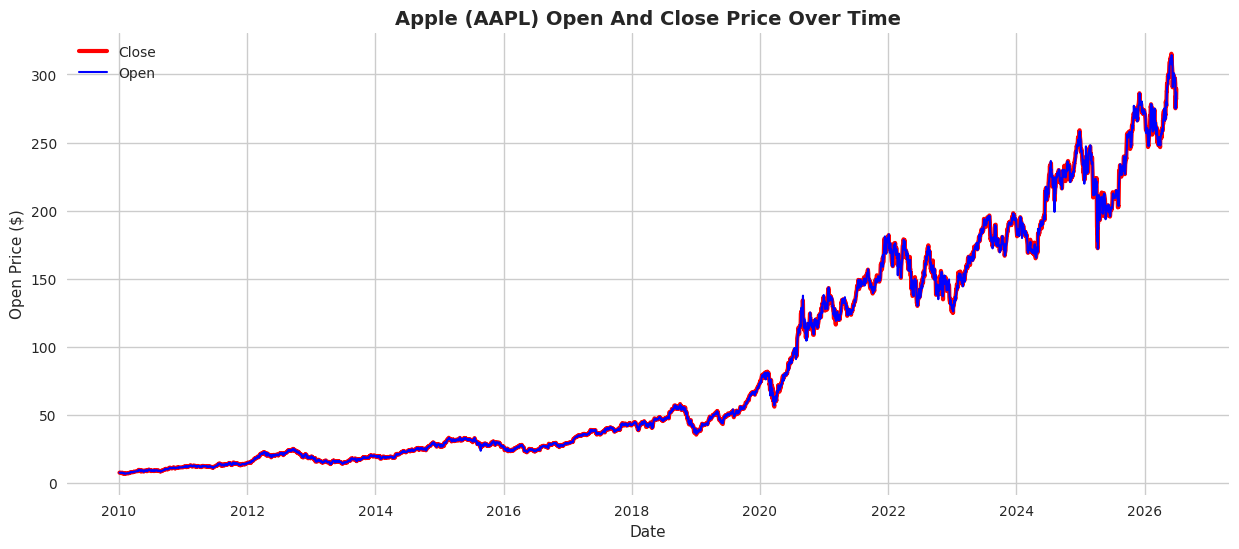

In [ ]:
# Open And Close Price Over Time
plt.figure(figsize=(15,6))
plt.plot(df.index, df['Close'],label='Close' ,color='red', linewidth=3)
plt.plot(df.index, df['Open'], label='Open',color='blue', linewidth=1.5)
plt.title('Apple (AAPL) Open And Close Price Over Time', fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Open Price ($)")
plt.grid(True)
plt.legend()
plt.show()

## Step 4.3 : Distribution of Open Price

Understanding the distribution of the Open price helps determine whether the data is symmetric, skewed, or contains outliers.

Financial data is often right-skewed and may not follow a normal distribution.

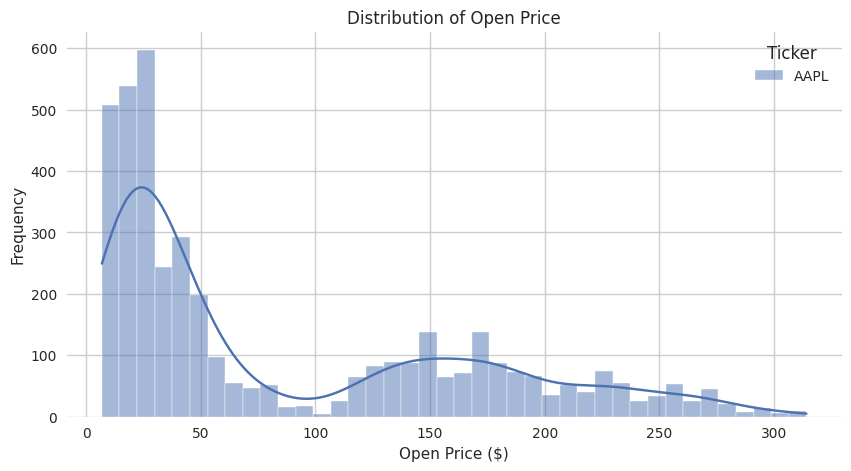

In [ ]:
# ==========================================================
# Step 4.3 : Distribution of Open Price
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(df["Open"],
             bins=40,
             kde=True)

plt.title("Distribution of Open Price")

plt.xlabel("Open Price ($)")

plt.ylabel("Frequency")

plt.show()

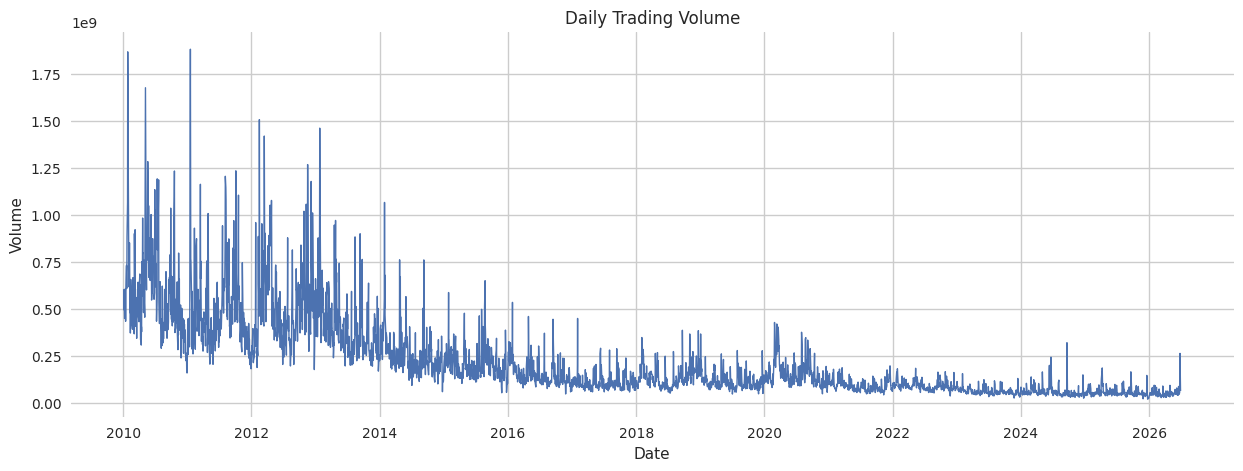

In [ ]:
# ==========================================================
# Step 4.4 : Volume Trend
# ==========================================================

plt.figure(figsize=(15,5))

plt.plot(df.index,
         df["Volume"],
         linewidth=1)

plt.title("Daily Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid(True)

plt.show()

## Step 4.5 : Correlation Analysis

The correlation matrix measures the linear relationship between numerical variables.

Although SARIMA models only one target variable, understanding relationships between OHLC prices provides useful insights into the dataset.

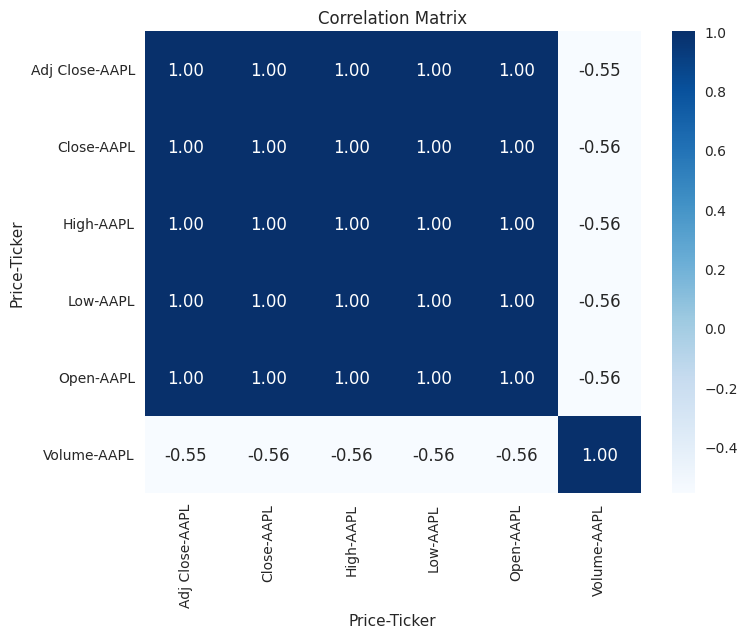

In [ ]:
# ==========================================================
# Step 4.5 : Correlation Matrix
# ==========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Step 4.6 : Rolling Mean and Rolling Standard Deviation

Rolling statistics help evaluate whether the mean and variance remain constant over time.

A stationary time series should have:

- Approximately constant mean
- Approximately constant variance

Significant changes suggest that differencing or transformation may be required before modeling.

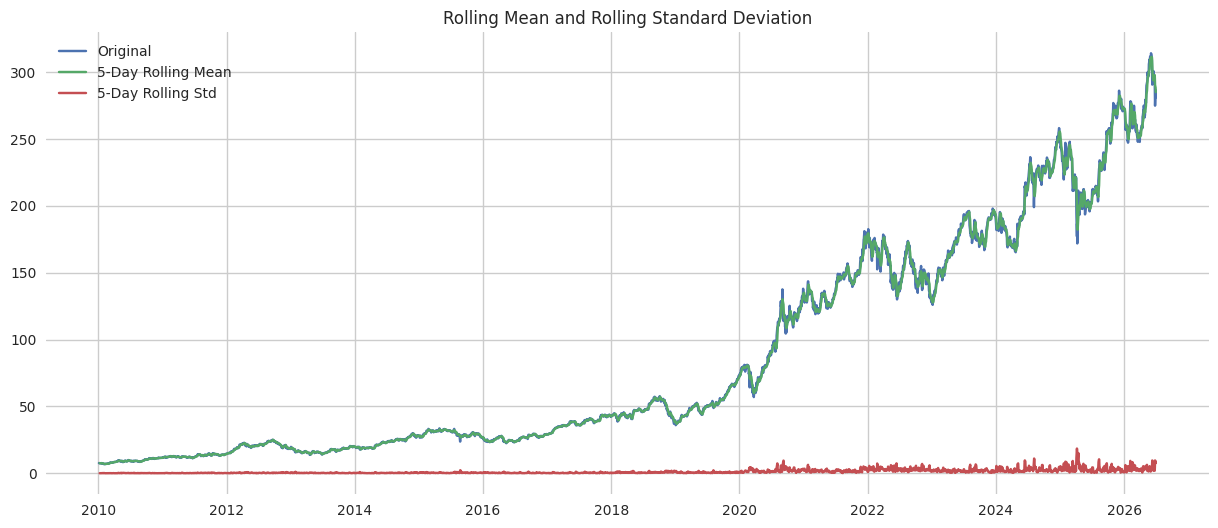

In [ ]:
# ==========================================================
# Step 4.6 : Rolling Statistics
# ==========================================================

rolling_mean = df["Open"].rolling(window=5).mean()

rolling_std = df["Open"].rolling(window=5).std()

plt.figure(figsize=(15,6))

plt.plot(df["Open"], label="Original")

plt.plot(rolling_mean,
         label="5-Day Rolling Mean")

plt.plot(rolling_std,
         label="5-Day Rolling Std")

plt.title("Rolling Mean and Rolling Standard Deviation")

plt.legend()

plt.grid(True)

plt.show()


In [ ]:
rolling_mean

Ticker,AAPL
Date,
2010-01-04,NaN
2010-01-05,NaN
2010-01-06,NaN
2010-01-07,NaN
2010-01-08,7.6033
...,...
2026-06-24,297.8340
2026-06-25,295.1440
2026-06-26,290.5220


## Step 4.4 : Kernel Density Estimation (KDE)

Kernel Density Estimation (KDE) provides a smooth estimate of the probability density function of the Open price.

Unlike a histogram, which depends on the choice of bin size, the KDE curve offers a continuous representation of the data distribution.

### Why is this important?

The KDE plot helps us:

- Understand the underlying distribution of the Open price.
- Detect skewness in the data.
- Identify whether the data is unimodal or multimodal.
- Observe the spread and concentration of values.

Financial time series often exhibit non-normal distributions due to market volatility.

In [ ]:
#Use to return a MultiIndex for the columns, even for a single ticker.
df.columns = df.columns.get_level_values(0)

In [ ]:
print(df.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


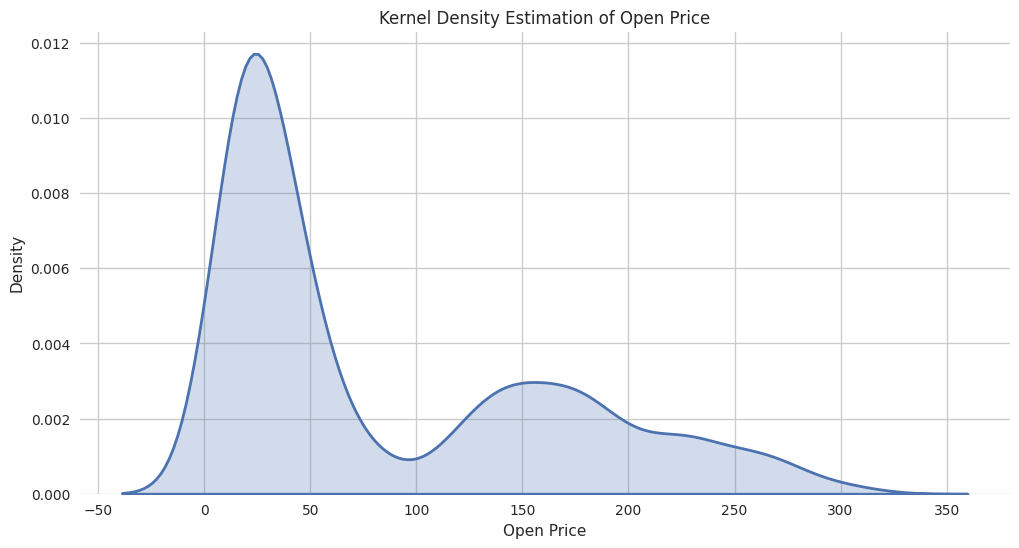

In [ ]:
# ==========================================================
# Step 4.4 : Kernel Density Estimation (KDE)
# ==========================================================

plt.figure(figsize=(12, 6))

sns.kdeplot(
    x=df["Open"],
    fill=True,
    linewidth=2
)

plt.title("Kernel Density Estimation of Open Price")
plt.xlabel("Open Price")
plt.ylabel("Density")
plt.grid(True)
plt.show()

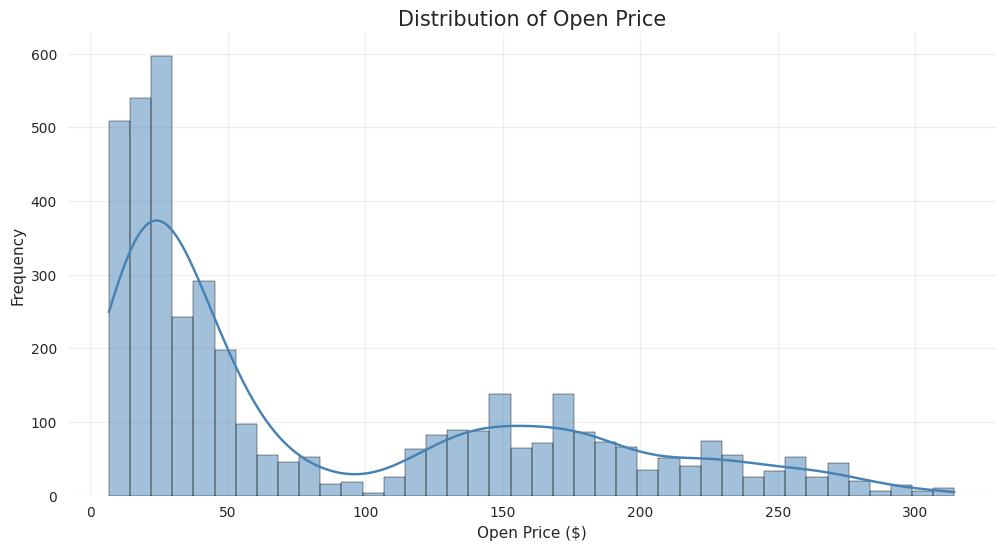

In [ ]:
# ==========================================================
# Step 4.4 : Histogram with KDE
# ==========================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Open",
    bins=40,
    kde=True,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Open Price", fontsize=15)
plt.xlabel("Open Price ($)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()


### Interpretation

From the KDE curve, we can observe:

- The overall shape of the Open price distribution.
- Whether the distribution is symmetric or skewed.
- Regions where stock prices are more concentrated.
- Whether multiple peaks (multimodal behavior) exist.

A skewed distribution is common in financial time series because stock prices generally exhibit long-term growth and periods of high volatility.

The KDE plot complements the histogram by providing a smoother representation of the distribution, making it easier to interpret the overall pattern.

## EDA Summary

### Observations

- The Open price exhibits a long-term trend.
- Price movements are highly volatile.
- The distribution is not perfectly normal.
- Trading volume varies substantially over time.
- OHLC variables are strongly correlated.
- Rolling statistics change over time, suggesting that the series is likely non-stationary.

### Conclusion

The Open price series appears to violate the stationarity assumption required by SARIMA.

Therefore, the next step is to formally test stationarity using the Augmented Dickey-Fuller (ADF) test and apply differencing if necessary.

# Step 5 : Stationarity Analysis

## Objective

Determine whether the Open Price time series is stationary.

## Why is this step required?

SARIMA assumes that the statistical properties of the time series remain constant over time.

A stationary time series has:

- Constant Mean
- Constant Variance
- Constant Covariance

However, stock prices generally exhibit trends and changing variance, making them non-stationary.

Before fitting a SARIMA model, we must verify stationarity and apply differencing if necessary.

## Methods Used

- Visual Inspection
- Rolling Mean
- Rolling Standard Deviation
- Augmented Dickey-Fuller (ADF) Test

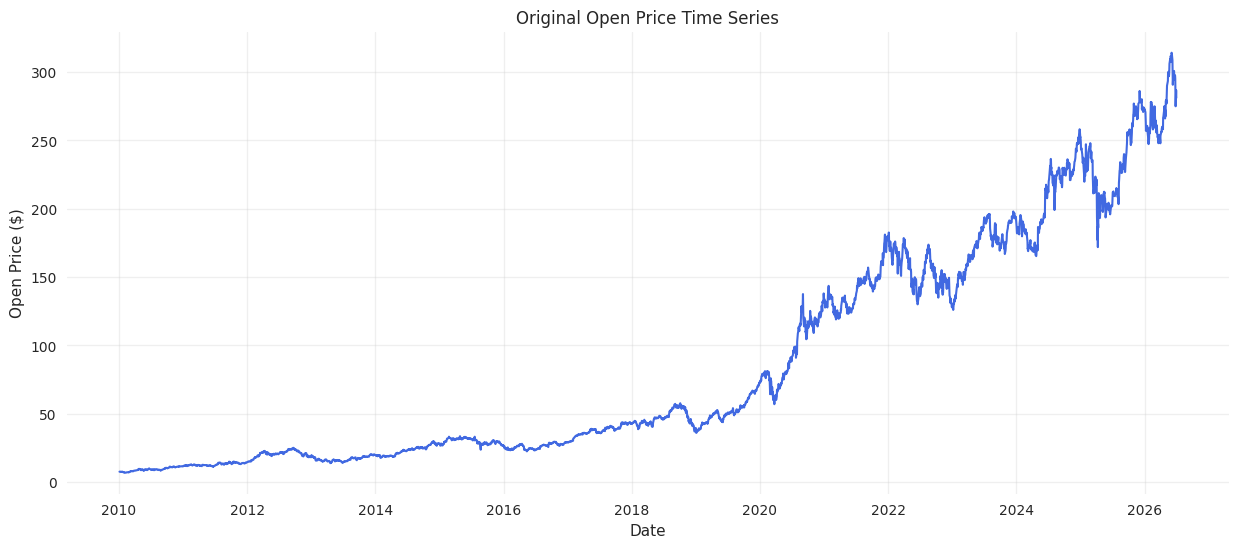

In [ ]:
# ==========================================================
# Step 5.1 : Original Time Series
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df["Open"],
    color="royalblue",
    linewidth=1.5
)

plt.title("Original Open Price Time Series")

plt.xlabel("Date")

plt.ylabel("Open Price ($)")

plt.grid(alpha=0.3)

plt.show()


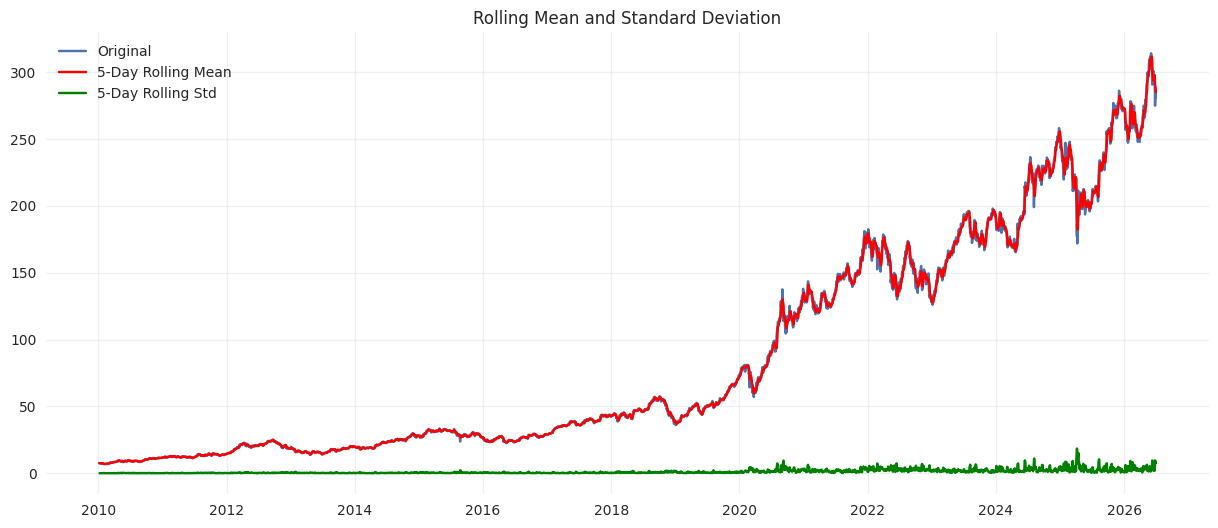

In [ ]:
# ==========================================================
# Step 5.2 : Rolling Statistics
# ==========================================================

rolling_mean = df["Open"].rolling(window=5).mean()

rolling_std = df["Open"].rolling(window=5).std()

plt.figure(figsize=(15,6))

plt.plot(df["Open"], label="Original")

plt.plot(rolling_mean,
         color="red",
         label="5-Day Rolling Mean")

plt.plot(rolling_std,
         color="green",
         label="5-Day Rolling Std")

plt.title("Rolling Mean and Standard Deviation")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Step 5.3 : Interpretation

Observe the following:

- Does the rolling mean remain approximately constant?
- Does the rolling standard deviation remain stable?
- Is there a visible trend?

If the answer is "No", the series is likely non-stationary and further statistical testing is required.

# Step 6 : Augmented Dickey-Fuller (ADF) Test

## Objective

Determine whether the Open Price time series is stationary using the Augmented Dickey-Fuller (ADF) statistical test.

---

## Why is this step required?

SARIMA requires a stationary time series.

While visual inspection provides an initial understanding, it is subjective.

The Augmented Dickey-Fuller (ADF) Test provides a statistical method to determine whether the time series contains a **unit root**, which indicates non-stationarity.

---

## Null Hypothesis (H₀)

The time series contains a unit root.

➡ The series is **non-stationary**.

---

## Alternative Hypothesis (H₁)

The time series does **not** contain a unit root.

➡ The series is **stationary**.

---

## Decision Rule

If

**p-value < 0.05**

Reject the Null Hypothesis.

The series is considered **stationary**.

Otherwise,

Fail to reject the Null Hypothesis.

The series is considered **non-stationary**.

In [ ]:
# ==========================================================
# Step 6 : Augmented Dickey-Fuller (ADF) Test
# ==========================================================

from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
adf_result = adfuller(df["Open"].dropna())

# Extract Results
adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lags = adf_result[2]
num_observations = adf_result[3]
critical_values = adf_result[4]

print("=" * 60)
print("Augmented Dickey-Fuller Test Results")
print("=" * 60)

print(f"ADF Statistic        : {adf_statistic:.6f}")
print(f"P-value              : {p_value:.6f}")
print(f"Number of Lags       : {used_lags}")
print(f"Observations Used    : {num_observations}")

print("\nCritical Values")

for key, value in critical_values.items():
    print(f"{key:<5} : {value:.6f}")

Augmented Dickey-Fuller Test Results
ADF Statistic        : 0.996132
P-value              : 0.994225
Number of Lags       : 29
Observations Used    : 4117

Critical Values
1%    : -3.431939
5%    : -2.862242
10%   : -2.567144


## ADF Test Interpretation

Interpret the results using the following rules:

### If p-value < 0.05

Reject the Null Hypothesis.

The Open Price series is stationary.

Differencing may not be required.

---

### If p-value ≥ 0.05

Fail to reject the Null Hypothesis.

The Open Price series is non-stationary.

Differencing is required before fitting the SARIMA model.

In [ ]:
# ==========================================================
# Step 6 : Conclusion of ADF Test
# ==========================================================

alpha = 0.05

print("=" * 60)

if p_value < alpha:
    print("Conclusion")
    print("=" * 60)
    print("The Open Price series is STATIONARY.")
    print("No differencing is required.")
else:
    print("Conclusion")
    print("=" * 60)
    print("The Open Price series is NON-STATIONARY.")
    print("Differencing is required before SARIMA.")


Conclusion
The Open Price series is NON-STATIONARY.
Differencing is required before SARIMA.


## Observation

The ADF test provides statistical evidence regarding the stationarity of the Open Price series.

If the p-value is greater than 0.05, the series is considered non-stationary and must be transformed before applying SARIMA.

The most common transformation is **first-order differencing**, which removes the trend and stabilizes the mean.

In the next step, we will apply first-order differencing and repeat the stationarity analysis to verify that the transformed series satisfies the assumptions of the SARIMA model.

# Step 7 : First-Order Differencing

## Objective

Transform the Open Price series into a stationary series by applying first-order differencing.

---

## Why is this step required?

The ADF test indicated that the original Open Price series is **non-stationary**.

One of the assumptions of the SARIMA model is that the input time series should be stationary.

First-order differencing removes the trend by calculating the difference between consecutive observations.

---

## Mathematical Formula

If

\[
Y_t
\]

is the original series,

then the first-order differenced series is

\[
Y'_t = Y_t - Y_{t-1}
\]

where

- \(Y_t\) = Current Observation
- \(Y_{t-1}\) = Previous Observation

---

## Expected Outcome

After differencing:

- Trend should reduce
- Mean should become more stable
- Variance should become more stable
- The series should be closer to stationarity

In [ ]:
# ==========================================================
# Step 7.1 : First-Order Differencing
# ==========================================================

# Create first-order differenced series
df["Open_Diff"] = df["Open"].diff()

# Remove missing value created by differencing
diff_data = df.dropna()

print("First-order differencing completed successfully.")

display(diff_data.head())

First-order differencing completed successfully.


Price,Adj Close,Close,High,Low,Open,Volume,Open_Diff
Date,,,,,,,
2010-01-05,6.4176,7.6564,7.6996,7.6161,7.6643,601904800,0.0418
2010-01-06,6.3155,7.5346,7.6868,7.5268,7.6564,552160000,-0.0079
2010-01-07,6.3038,7.5207,7.5714,7.4661,7.5625,477131200,-0.0939
2010-01-08,6.3457,7.5707,7.5714,7.4664,7.5107,447610800,-0.0518
2010-01-11,6.2897,7.5039,7.6071,7.4446,7.6000,462229600,0.0893


## Step 7.2 : Visualize the Differenced Series

The differenced series should fluctuate around a relatively constant mean without a noticeable long-term trend.

This provides an initial visual assessment of whether the transformation has improved stationarity.

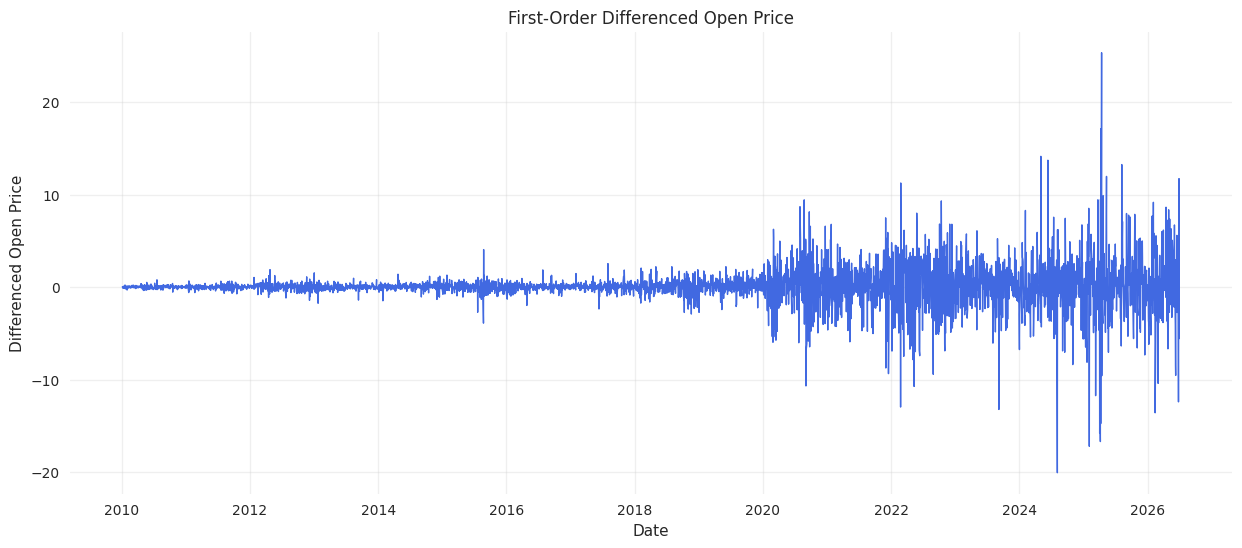

In [ ]:
# ==========================================================
# Step 7.2 : Plot Differenced Series
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    diff_data.index,
    diff_data["Open_Diff"],
    color="royalblue",
    linewidth=1
)

plt.title("First-Order Differenced Open Price")

plt.xlabel("Date")

plt.ylabel("Differenced Open Price")

plt.grid(alpha=0.3)

plt.show()

## Step 7.3 : Rolling Mean and Rolling Standard Deviation

Rolling statistics are recalculated after differencing.

If the rolling mean and rolling standard deviation remain approximately constant over time, the differenced series is likely stationary.

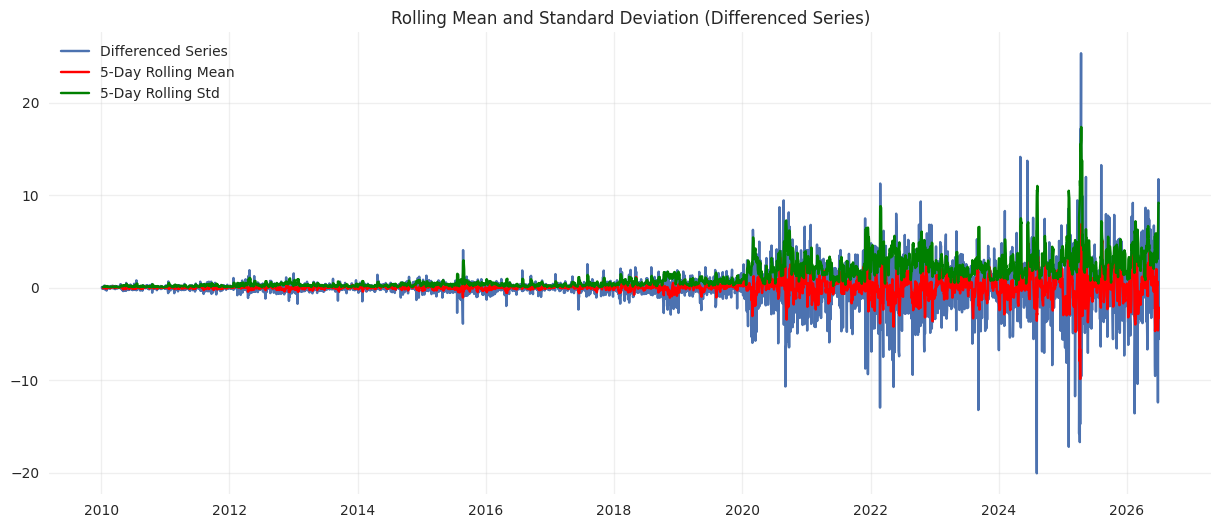

In [ ]:
# ==========================================================
# Step 7.3 : Rolling Statistics
# ==========================================================

rolling_mean = diff_data["Open_Diff"].rolling(window=5).mean()

rolling_std = diff_data["Open_Diff"].rolling(window=5).std()

plt.figure(figsize=(15,6))

plt.plot(
    diff_data["Open_Diff"],
    label="Differenced Series"
)

plt.plot(
    rolling_mean,
    color="red",
    label="5-Day Rolling Mean"
)

plt.plot(
    rolling_std,
    color="green",
    label="5-Day Rolling Std"
)

plt.title("Rolling Mean and Standard Deviation (Differenced Series)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Step 7.4 : Re-run the ADF Test

After differencing, we repeat the ADF test to statistically verify whether the transformed series has become stationary.

This is an essential step before selecting SARIMA parameters.

In [ ]:
# ==========================================================
# Step 7.4 : ADF Test on Differenced Series
# ==========================================================

from statsmodels.tsa.stattools import adfuller

adf_result_diff = adfuller(diff_data["Open_Diff"])

print("=" * 60)
print("ADF Test on First-Order Differenced Series")
print("=" * 60)

print(f"ADF Statistic : {adf_result_diff[0]:.6f}")
print(f"P-value       : {adf_result_diff[1]:.6f}")
print(f"Lags Used     : {adf_result_diff[2]}")
print(f"Observations  : {adf_result_diff[3]}")

print("\nCritical Values")

for key, value in adf_result_diff[4].items():
    print(f"{key:<5} : {value:.6f}")

ADF Test on First-Order Differenced Series
ADF Statistic : -11.889337
P-value       : 0.000000
Lags Used     : 31
Observations  : 4114

Critical Values
1%    : -3.431941
5%    : -2.862243
10%   : -2.567144


In [ ]:
# ==========================================================
# Step 7.5 : Final Interpretation
# ==========================================================

alpha = 0.05

print("=" * 60)

if adf_result_diff[1] < alpha:
    print("Conclusion")
    print("=" * 60)
    print("The differenced series is STATIONARY.")
    print("The differencing order is d = 1.")
else:
    print("Conclusion")
    print("=" * 60)
    print("The differenced series is still NON-STATIONARY.")
    print("Consider second-order differencing (d = 2) only if justified.")

Conclusion
The differenced series is STATIONARY.
The differencing order is d = 1.


## Observation

The first-order differenced series should exhibit reduced trend and a more stable mean.

If the ADF test returns a p-value less than 0.05, the differenced series is considered stationary.

In that case:

- Differencing order (**d**) = 1
- The series is ready for autocorrelation analysis.

If the series remains non-stationary, further investigation is required before increasing the differencing order.

# Step 8 : ACF and PACF Analysis

## Objective

Analyze the autocorrelation structure of the stationary time series to estimate the initial values of the SARIMA model parameters.

---

## Why is this step required?

After making the series stationary, we need to determine the appropriate values for:

- **p** : AutoRegressive (AR) order
- **q** : Moving Average (MA) order

The ACF and PACF plots help us estimate these values.

---

## What is ACF?

The **Autocorrelation Function (ACF)** measures the correlation between the current observation and its previous observations (lags).

ACF is primarily used to estimate the **Moving Average (MA)** order (**q**).

---

## What is PACF?

The **Partial Autocorrelation Function (PACF)** measures the direct correlation between observations after removing the influence of intermediate lags.

PACF is primarily used to estimate the **AutoRegressive (AR)** order (**p**).

---

## Relationship

- PACF → Estimate **p**
- ACF → Estimate **q**

These estimates provide starting values that will later be validated by model diagnostics and evaluation metrics.

<Figure size 1200x500 with 0 Axes>

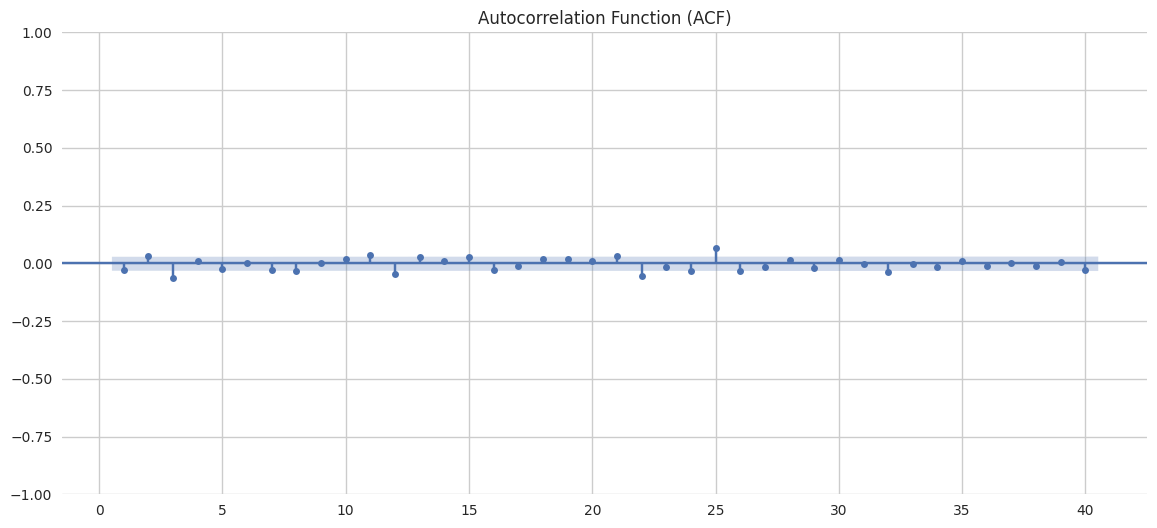

In [ ]:
# ==========================================================
# Step 8.1 : ACF Plot
# ==========================================================

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    diff_data["Open_Diff"],
    lags=40,
    zero=False
)

plt.title("Autocorrelation Function (ACF)")

plt.show()


## Interpretation of ACF

The ACF plot helps estimate the Moving Average order (**q**).

Observe:

- Where autocorrelation cuts off.
- Where the bars fall inside the confidence interval.
- Significant spikes indicate useful lag relationships.
-

<Figure size 1200x500 with 0 Axes>

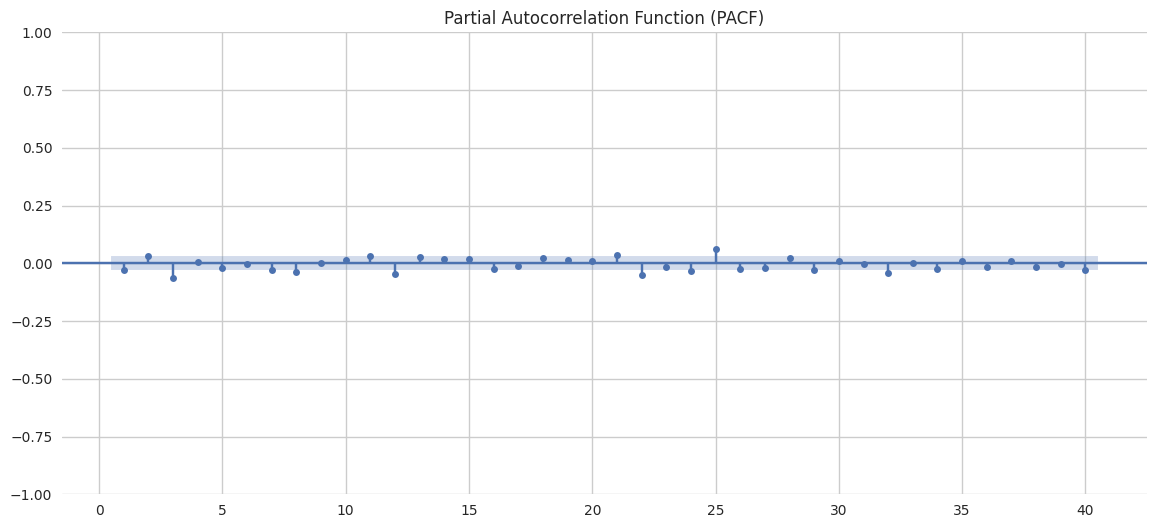

In [ ]:
# ==========================================================
# Step 8.2 : PACF Plot
# ==========================================================

from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    diff_data["Open_Diff"],
    lags=40,
    zero=False,
    method="ywm"
)

plt.title("Partial Autocorrelation Function (PACF)")

plt.show()

## Interpretation of PACF

The PACF plot helps estimate the AutoRegressive order (**p**).

Observe:

- Significant spikes at the first few lags.
- Where the spikes become statistically insignificant.
- The cutoff point provides an initial estimate of **p**.

## General Interpretation Guide

| Plot | Purpose | Parameter |
|------|---------|-----------|
| PACF | AutoRegressive Component | p |
| ACF | Moving Average Component | q |

### Typical Patterns

#### AR Process

- PACF cuts off
- ACF tails off

#### MA Process

- ACF cuts off
- PACF tails off

#### ARMA Process

- Both ACF and PACF tail off

In [ ]:
# ==========================================================
# Step 8.3 : Suggested Initial Parameters
# ==========================================================

print("=" * 60)
print("Initial SARIMA Parameter Selection")
print("=" * 60)

print("Use the ACF plot to estimate q.")
print("Use the PACF plot to estimate p.")
print("The differencing order d was determined using the ADF test.")
print("\nThese are starting values only and should be validated during model fitting.")


Initial SARIMA Parameter Selection
Use the ACF plot to estimate q.
Use the PACF plot to estimate p.
The differencing order d was determined using the ADF test.

These are starting values only and should be validated during model fitting.


## Observation

Based on the ACF and PACF plots:

- Estimate an initial value for **p**.
- Estimate an initial value for **q**.
- The differencing order (**d**) has already been determined.

These values will be used as the initial SARIMA configuration.

The final model should be selected based on forecasting performance and residual diagnostics rather than ACF/PACF alone.

# Step 9 : Train-Test Split

## Objective

Split the time series into training and testing datasets while preserving chronological order.

---

## Why is this step required?

Unlike traditional machine learning, time series data cannot be randomly shuffled.

The model must learn only from past observations and be evaluated on future observations.

Random splitting causes **data leakage**, where information from the future is used during training, leading to overly optimistic performance estimates.

---

## Train-Test Ratio

Training Data : **80%**

Testing Data : **20%**

---

## Time Series Split

Historical Data
────────────────────────────────────────────

██████████████████████████████░░░░░░░░

      Training (80%)        Testing (20%)


In [ ]:
# ==========================================================
# Step 9.1 : Create Time Series
# ==========================================================

# Select only the Open price
ts = df["Open"].copy()

print("Target Variable :", ts.name)
print("Total Observations :", len(ts))

Target Variable : Open
Total Observations : 4147


In [ ]:
# ==========================================================
# Step 9.2 : Train-Test Split
# ==========================================================

# Split index
split_index = int(len(ts) * 0.80)

# Training dataset
train = ts.iloc[:split_index]

# Testing dataset
test = ts.iloc[split_index:]

print("=" * 60)
print("Train-Test Split Completed")
print("=" * 60)

print(f"Training Samples : {len(train)}")
print(f"Testing Samples  : {len(test)}")

Train-Test Split Completed
Training Samples : 3317
Testing Samples  : 830


## Verify Date Range

The testing dataset must begin immediately after the training dataset.

There should be:

- No overlap
- No shuffling
- No missing observations caused by the split

In [ ]:
# ==========================================================
# Step 9.3 : Verify Date Ranges
# ==========================================================

print("Training Data")

print("Start :", train.index.min())

print("End   :", train.index.max())

print()

print("Testing Data")

print("Start :", test.index.min())

print("End   :", test.index.max())

Training Data
Start : 2010-01-04 00:00:00
End   : 2023-03-08 00:00:00

Testing Data
Start : 2023-03-09 00:00:00
End   : 2026-06-30 00:00:00


## Visualize the Split

The following graph confirms that the dataset has been divided chronologically.

Blue Line → Training Data

Orange Line → Testing Data

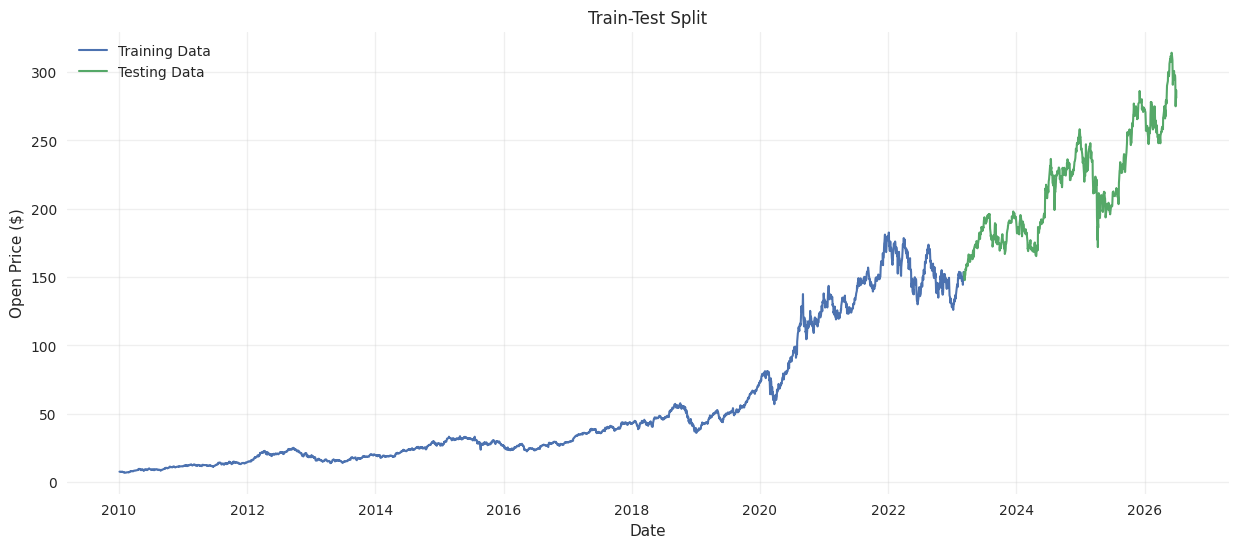

In [ ]:
# ==========================================================
# Step 9.4 : Visualize Train-Test Split
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    train,
    label="Training Data",
    linewidth=1.5
)

plt.plot(
    test,
    label="Testing Data",
    linewidth=1.5
)

plt.title("Train-Test Split")

plt.xlabel("Date")

plt.ylabel("Open Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


## Observation

The historical time series has been successfully divided into training and testing datasets.

Key observations:

- The chronological order has been preserved.
- No future observations are included in the training data.
- The testing data represents unseen observations for evaluating the forecasting model.

The training dataset will be used to estimate the SARIMA parameters, while the testing dataset will be reserved exclusively for performance evaluation.

# Step 10 : SARIMA Hyperparameter Selection

## Objective

Identify the optimal SARIMA parameters by comparing multiple candidate models.

---

## Why is this step required?

The ACF and PACF plots provide only initial estimates of the SARIMA parameters.

Several candidate models may fit the data well.

Therefore, we compare multiple parameter combinations and select the model with the lowest Akaike Information Criterion (AIC).

---

## Model Selection Criterion

This project uses **AIC (Akaike Information Criterion)**.

A lower AIC generally indicates a better balance between model fit and complexity.

The parameter combination with the lowest AIC will be selected for final model training.

In [ ]:
# ==========================================================
# Step 10.1 : Grid Search using AIC
# ==========================================================

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Candidate parameters
p = range(0, 3)
d = [1]
q = range(0, 3)

P = range(0, 2)
D = [1]
Q = range(0, 2)
m = 5

parameter_combinations = list(
    itertools.product(p, d, q, P, D, Q)
)

results = []

print("Searching for the best SARIMA model...")

Searching for the best SARIMA model...


In [ ]:
# ==========================================================
# Step 10.2 : Fit Candidate Models
# ==========================================================

for param in parameter_combinations:

    try:

        model = SARIMAX(
            train,
            order=(param[0], param[1], param[2]),
            seasonal_order=(param[3], param[4], param[5], m),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        results.append([
            param,
            fitted_model.aic
        ])

    except:
        continue

In [ ]:
# ==========================================================
# Step 10.3 : Best Parameters
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=["Parameters", "AIC"]
)

results_df = results_df.sort_values("AIC")

display(results_df.head(100))

,Parameters,AIC
9,"(0, 1, 2, 0, 1, 1)",11913.1947
21,"(1, 1, 2, 0, 1, 1)",11914.9046
11,"(0, 1, 2, 1, 1, 1)",11915.1931
17,"(1, 1, 1, 0, 1, 1)",11915.3774
33,"(2, 1, 2, 0, 1, 1)",11916.2013
29,"(2, 1, 1, 0, 1, 1)",11916.8320
23,"(1, 1, 2, 1, 1, 1)",11916.9566
19,"(1, 1, 1, 1, 1, 1)",11917.3746
35,"(2, 1, 2, 1, 1, 1)",11918.1884
31,"(2, 1, 1, 1, 1, 1)",11918.8292


In [ ]:
# ==========================================================
# Step 10.4 : Select Best Model
# ==========================================================

best_parameters = results_df.iloc[0]

print("=" * 60)

print("Best SARIMA Parameters")

print("=" * 60)

print(best_parameters)

Best SARIMA Parameters
Parameters    (0, 1, 2, 0, 1, 1)
AIC                   11913.1947
Name: 9, dtype: object


# Step 11 : SARIMA Model Development and Training

## Objective

Train the final SARIMA model using the optimal parameters obtained from the AIC-based Grid Search.

---

## Why is this step required?

After identifying the best SARIMA configuration, the model is trained using the historical training dataset.

During training, the model estimates the coefficients of:

- AutoRegressive (AR)
- Moving Average (MA)
- Seasonal AR
- Seasonal MA

using Maximum Likelihood Estimation (MLE).

The trained model will then be used for forecasting the unseen testing dataset.

---

## Selected Model

Non-Seasonal Order

**(p,d,q) = (0,1,2)**

Seasonal Order

**(P,D,Q,m) = (0,1,1,5)**

These parameters were selected because they produced the lowest AIC during the Grid Search.

In [ ]:
# ==========================================================
# Step 11.1 : Train Final SARIMA Model
# ==========================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build Model
model = SARIMAX(
    train,
    order=(0, 1, 2),
    seasonal_order=(0, 1, 1, 5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Train Model
sarima_model = model.fit(disp=False)

print("=" * 60)
print("SARIMA Model Trained Successfully")
print("=" * 60)

SARIMA Model Trained Successfully


## Model Summary

The statistical summary provides detailed information about the fitted SARIMA model.

Important statistics include:

- Estimated coefficients
- Standard Errors
- z-statistics
- p-values
- Log Likelihood
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)
- Residual Diagnostics

These values help determine whether the selected model is statistically reasonable.

In [ ]:
# ==========================================================
# Step 11.2 : Model Summary
# ==========================================================

print(sarima_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                Open   No. Observations:                 3317
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 5)   Log Likelihood               -5952.597
Date:                             Wed, 01 Jul 2026   AIC                          11913.195
Time:                                     07:33:54   BIC                          11937.605
Sample:                                          0   HQIC                         11921.932
                                            - 3317                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0714      0.007     -9.662      0.000      -0.086      -0.057
ma.L2         -0.0403      

## Model Interpretation

While reviewing the SARIMA summary, pay attention to the following:

### 1. AIC
Lower values indicate a better balance between model fit and complexity.

### 2. BIC
Similar to AIC but applies a stronger penalty for model complexity.

### 3. Log Likelihood
Higher values generally indicate a better fit.

### 4. Coefficients

Each AR and MA coefficient represents the contribution of previous observations or forecast errors.

### 5. p-values

A coefficient is generally considered statistically significant if:

**p-value < 0.05**

### 6. Ljung-Box Test

Tests whether residuals are independent.

A high p-value (> 0.05) suggests no significant autocorrelation remains.

### 7. Jarque-Bera Test

Evaluates whether residuals follow a normal distribution.

### 8. Heteroskedasticity Test

Checks whether the variance of residuals is constant over time.

In [ ]:
# ==========================================================
# Step 11.3 : Important Model Statistics
# ==========================================================

print("=" * 60)
print("Model Statistics")
print("=" * 60)

print(f"AIC            : {sarima_model.aic:.4f}")
print(f"BIC            : {sarima_model.bic:.4f}")
print(f"Log Likelihood : {sarima_model.llf:.4f}")

Model Statistics
AIC            : 11913.1947
BIC            : 11937.6050
Log Likelihood : -5952.5973


## Observation

The SARIMA model has been successfully trained using the historical training data.

The estimated coefficients and statistical diagnostics indicate how well the model captures the temporal structure of the Open Price series.

The trained model is now ready to generate forecasts for the unseen testing dataset.

Before forecasting, it is recommended to analyze the residuals to ensure that the model has captured the underlying patterns effectively.

# Step 12 : Residual Diagnostics

## Objective

Evaluate whether the residuals of the fitted SARIMA model satisfy the assumptions of a good forecasting model.

---

## Why is this step required?

Residuals represent the difference between the observed values and the values predicted by the model.

A well-fitted SARIMA model should leave only random noise in the residuals.

Ideally, the residuals should:

- Have a mean close to zero.
- Exhibit constant variance.
- Show no autocorrelation.
- Follow an approximately normal distribution.

Residual diagnostics help determine whether the model has adequately captured the underlying structure of the time series.

---

## Residual Analysis Performed

- Residual Time Series
- Residual Distribution
- Residual KDE
- Q-Q Plot
- Residual ACF
- Ljung-Box Test
-

In [ ]:
# ==========================================================
# Step 12.1 : Extract Residuals
# ==========================================================

residuals = sarima_model.resid

print("Residuals extracted successfully.")

display(residuals.head())

Residuals extracted successfully.


,0
Date,
2010-01-04,7.6225
2010-01-05,0.0418
2010-01-06,-0.0079
2010-01-07,-0.0939
2010-01-08,-0.0518


## Step 12.2 : Residual Time Series

The residual plot helps identify:

- Remaining trends
- Sudden spikes
- Changing variance

A good SARIMA model should produce residuals that fluctuate randomly around zero.

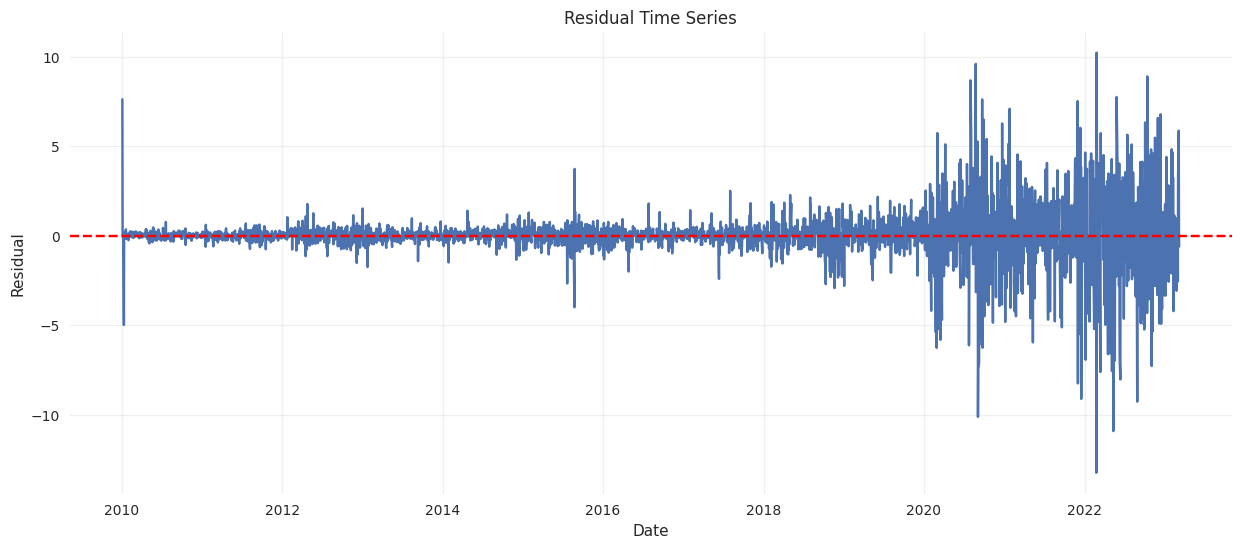

In [ ]:
# ==========================================================
# Step 12.2 : Residual Plot
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(residuals)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Time Series")

plt.xlabel("Date")

plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.show()

## Step 12.3 : Histogram of Residuals

A histogram provides an overview of the distribution of residual values.

Ideally, the histogram should resemble a bell-shaped distribution centered around zero.

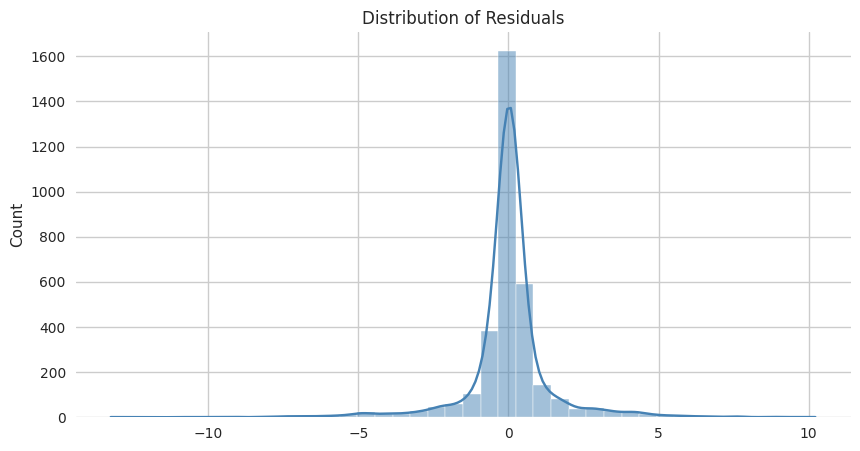

In [ ]:
# ==========================================================
# Step 12.3 : Histogram
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Residuals")

plt.show()

## Step 12.4 : Kernel Density Estimation (KDE)

The KDE plot provides a smooth estimate of the residual distribution.

A symmetric curve centered around zero suggests that the residuals are approximately normally distributed.

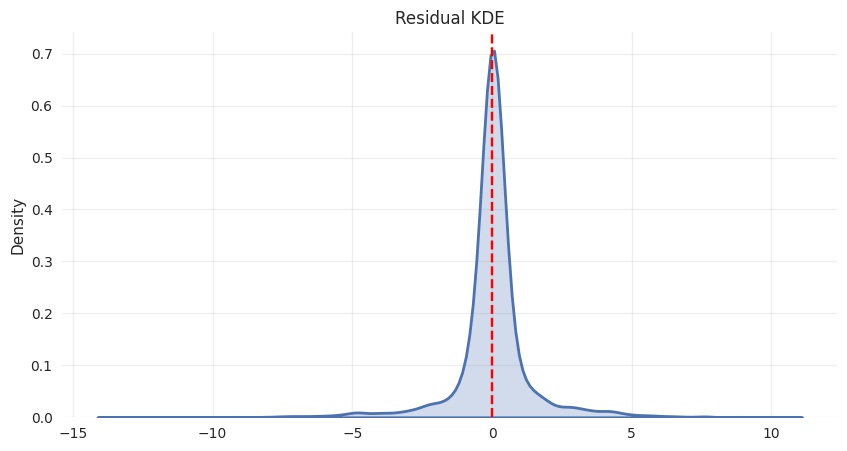

In [ ]:
# ==========================================================
# Step 12.4 : KDE Plot
# ==========================================================

plt.figure(figsize=(10,5))

sns.kdeplot(
    residuals,
    fill=True,
    linewidth=2
)

plt.axvline(0, color="red", linestyle="--")

plt.title("Residual KDE")

plt.grid(alpha=0.3)

plt.show()

## Step 12.6 : Residual Autocorrelation

Residuals should not exhibit significant autocorrelation.

If autocorrelation remains, the model has not fully captured the temporal structure of the data.

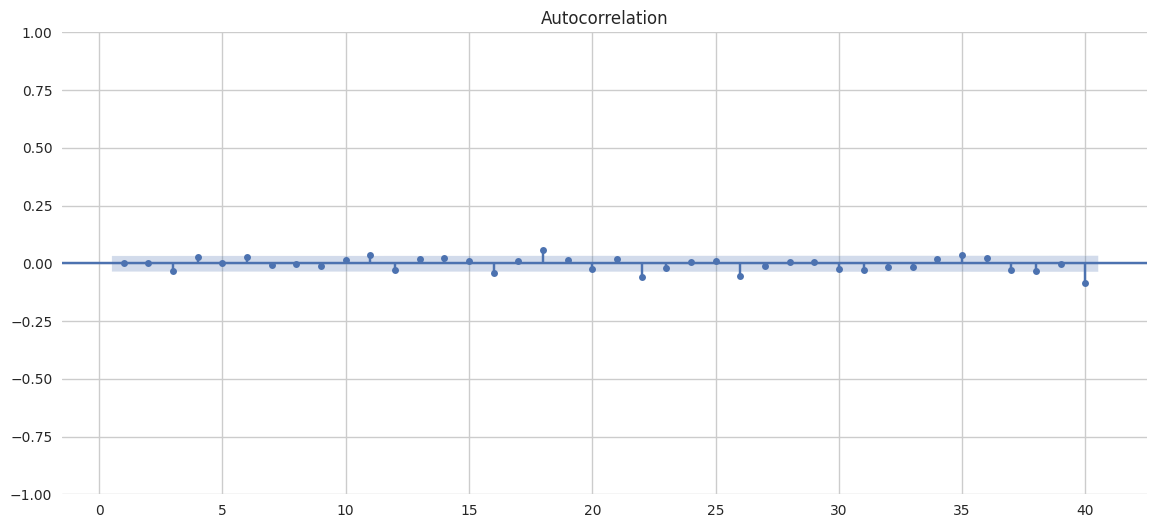

In [ ]:
# ==========================================================
# Step 12.6 : Residual ACF
# ==========================================================

plot_acf(
    residuals,
    lags=40,
    zero=False
)

plt.show()

## Step 12.7 : Ljung-Box Test

The Ljung-Box test checks whether residual autocorrelation remains.

### Null Hypothesis (H₀)

Residuals are independently distributed.

### Alternative Hypothesis (H₁)

Residuals contain autocorrelation.

If the p-value is greater than 0.05, the residuals behave like white noise.

In [ ]:
# ==========================================================
# Step 12.7 : Ljung-Box Test
# ==========================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

display(lb_test)

,lb_stat,lb_pvalue
10,10.2028,0.4229


In [ ]:
# ==========================================================
# Step 12.8 : Residual Statistics
# ==========================================================

print("="*60)
print("Residual Statistics")
print("="*60)

print(f"Mean      : {residuals.mean():.6f}")
print(f"Std Dev   : {residuals.std():.6f}")
print(f"Minimum   : {residuals.min():.6f}")
print(f"Maximum   : {residuals.max():.6f}")

Residual Statistics
Mean      : 0.026086
Std Dev   : 1.467559
Minimum   : -13.250387
Maximum   : 10.224270


## Observation

The residual diagnostics indicate whether the fitted SARIMA model adequately explains the observed time series.

A satisfactory model should satisfy the following conditions:

- Residuals fluctuate randomly around zero.
- The histogram and KDE are approximately symmetric.
- The ACF plot shows no significant autocorrelation.
- The Ljung-Box test produces a p-value greater than 0.05.

If these conditions are met, the residuals can be considered approximately white noise, suggesting that the SARIMA model has captured the underlying structure of the data effectively.

The model is now ready for forecasting on the unseen testing dataset.

# Step 13 : Forecasting and Model Evaluation

## Objective

Generate forecasts for the testing dataset and evaluate the forecasting performance of the SARIMA model.

---

## Why is this step required?

After training the SARIMA model, its performance must be evaluated using unseen data.

The testing dataset simulates future observations that were not available during training.

Comparing the predicted values with the actual values allows us to assess the forecasting accuracy of the model.

---

## Evaluation Metrics

The following metrics will be used:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics provide complementary information about forecasting performance.

In [ ]:
# ==========================================================
# Step 13.1 : Forecast Test Dataset
# ==========================================================
forecast = sarima_model.forecast(steps=len(test))

forecast.name = "Predicted_Open"

forecast.index = test.index

forecast.head(10)

,Predicted_Open
Date,
2023-03-09,152.8949
2023-03-10,153.0263
2023-03-13,153.0534
2023-03-14,153.1030
2023-03-15,153.0795
2023-03-16,153.1382
2023-03-17,153.2455
2023-03-20,153.2725
2023-03-21,153.3221


## Visual Comparison

The following graph compares the actual Open prices with the SARIMA predictions over the testing period.

A good forecasting model should produce predictions that closely follow the actual observations.


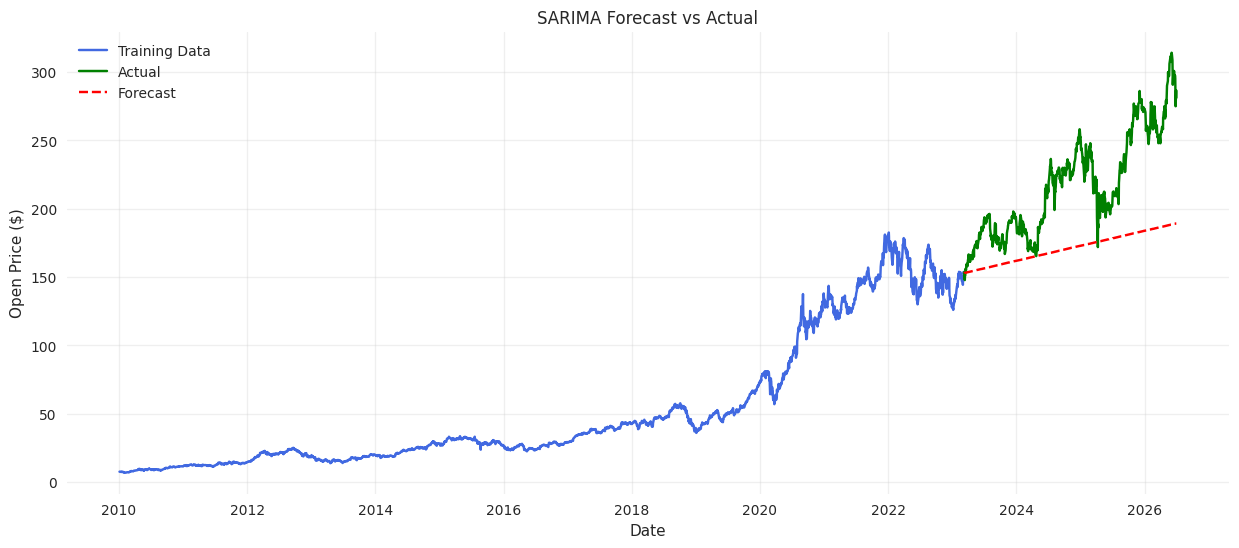

In [ ]:
# ==========================================================
# Step 13.2 : Actual vs Predicted
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    train,
    label="Training Data",
    color="royalblue"
)

plt.plot(
    test,
    label="Actual",
    color="green"
)

plt.plot(
    forecast,
    label="Forecast",
    color="red",
    linestyle="--"
)

plt.title("SARIMA Forecast vs Actual")

plt.xlabel("Date")

plt.ylabel("Open Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ==========================================================
# Step 13.1 : Forecast Train Dataset
# ==========================================================
forecasts = sarima_model.forecast(steps=len(train))

forecasts.name = "Predicted_Open"

forecasts.index = train.index

forecasts.head(10)

,Predicted_Open
Date,
2010-01-04,152.8949
2010-01-05,153.0263
2010-01-06,153.0534
2010-01-07,153.1030
2010-01-08,153.0795
2010-01-11,153.1382
2010-01-12,153.2455
2010-01-13,153.2725
2010-01-14,153.3221


In [ ]:
df['Open']

,Open
Date,
2010-01-04,7.6225
2010-01-05,7.6643
2010-01-06,7.6564
2010-01-07,7.5625
2010-01-08,7.5107
...,...
2026-06-24,295.3600
2026-06-25,287.4000
2026-06-26,275.0000


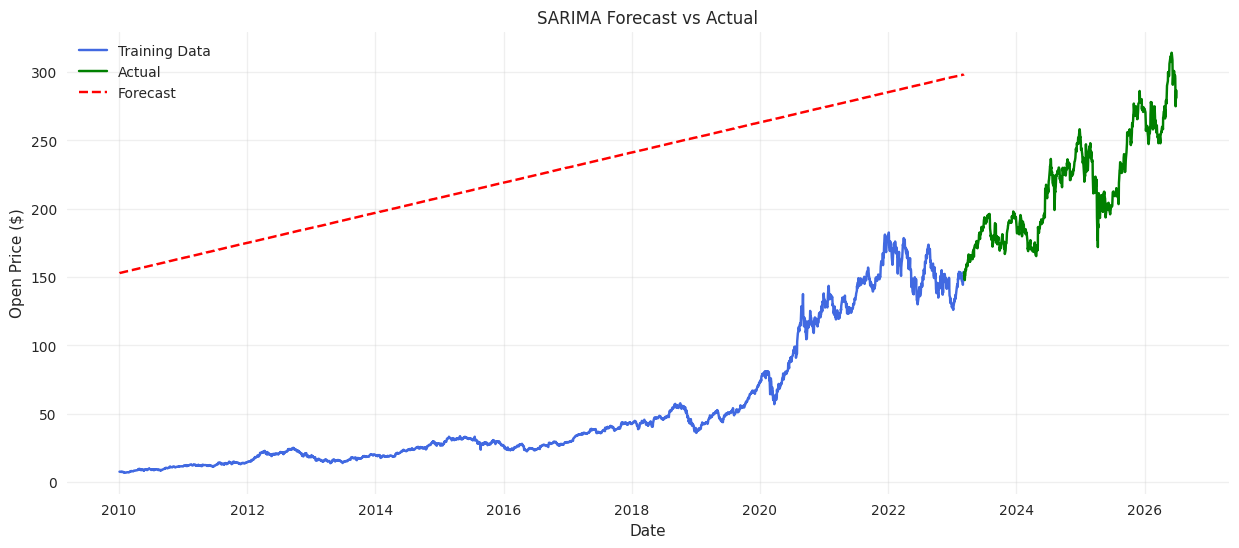

In [ ]:

plt.figure(figsize=(15,6))

plt.plot(
    train,
    label="Training Data",
    color="royalblue"
)

plt.plot(
    test,
    label="Actual",
    color="green"
)

plt.plot(
    forecasts,
    label="Forecast",
    color="red",
    linestyle="--"
)

plt.title("SARIMA Forecast vs Actual")

plt.xlabel("Date")

plt.ylabel("Open Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Forecast Error

Forecast error is defined as:

Residual = Actual − Predicted

Analyzing forecast errors helps identify systematic underestimation or overestimation by the model.

In [ ]:
# ==========================================================
# Step 13.3 : Forecast Errors
# ==========================================================

forecast_error = test - forecast

forecast_error.head()

,0
Date,
2023-03-09,0.6651
2023-03-10,-2.8163
2023-03-13,-5.2434
2023-03-14,-1.8230
2023-03-15,-1.8895


## Distribution of Forecast Errors

The error distribution provides insight into the forecasting behavior.

Ideally, the errors should be centered around zero with no significant skewness.

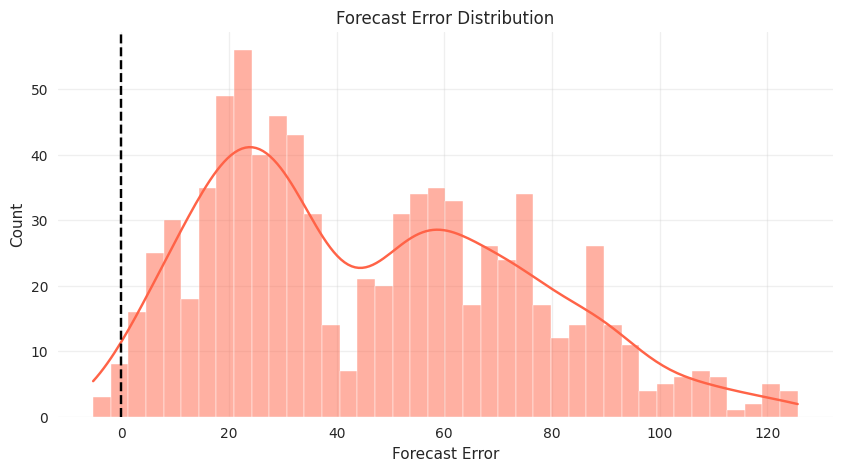

In [ ]:
# ==========================================================
# Step 13.4 : Forecast Error Distribution
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    forecast_error,
    bins=40,
    kde=True,
    color="tomato"
)

plt.axvline(0, color="black", linestyle="--")

plt.title("Forecast Error Distribution")

plt.xlabel("Forecast Error")

plt.grid(alpha=0.3)

plt.show()

## Calculate Evaluation Metrics

To objectively evaluate forecasting performance, we compute:

- MAE
- RMSE
- MAPE

Lower values indicate better forecasting accuracy.

In [ ]:
# ==========================================================
# Step 13.5 : Evaluation Metrics
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

mape = mean_absolute_percentage_error(
    test,
    forecast
)

print("=" * 60)
print("SARIMA Model Performance")
print("=" * 60)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape*100:.2f}%")

SARIMA Model Performance
MAE  : 46.2528
RMSE : 54.5240
MAPE : 19.69%


## Interpretation of Metrics

### Mean Absolute Error (MAE)

Represents the average absolute difference between actual and predicted values.

Lower MAE indicates better accuracy.

---

### Root Mean Squared Error (RMSE)

Gives higher weight to large prediction errors.

Lower RMSE indicates better model performance.

---

### Mean Absolute Percentage Error (MAPE)

Measures the prediction error as a percentage.

A lower MAPE indicates better forecasting accuracy.

These metrics should be interpreted together rather than individually.

## Observation

The SARIMA model has generated forecasts for the unseen testing dataset.

The comparison between actual and predicted values, along with the evaluation metrics, provides an objective assessment of the model's forecasting performance.

Although the model captures the general trend of the Open price series, deviations may occur due to the inherent volatility and unpredictability of the stock market.

The forecasting performance should be interpreted considering the limitations of statistical time series models when applied to financial data.

# Step 14 : Model Performance Evaluation

## Objective

Evaluate the forecasting accuracy of the SARIMA model using quantitative performance metrics.

---

## Why is this step required?

Visual inspection alone is insufficient to judge the quality of a forecasting model.

Quantitative evaluation provides an objective measure of prediction accuracy and enables comparison with other forecasting models.

---

## Evaluation Metrics

The following metrics are used:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

Each metric measures forecasting performance from a different perspective.

In [ ]:
# ==========================================================
# Step 14.1 : Calculate Performance Metrics
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = mean_absolute_percentage_error(test, forecast)

print("="*60)
print("SARIMA Performance Metrics")
print("="*60)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape*100:.2f}%")

SARIMA Performance Metrics
MAE  : 46.2528
RMSE : 54.5240
MAPE : 19.69%


In [ ]:
# ==========================================================
# Step 14.2 : Performance Summary Table
# ==========================================================

performance = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE (%)"],
    "Value": [
        round(mae,4),
        round(rmse,4),
        round(mape*100,2)
    ]
})

performance


,Metric,Value
0,MAE,46.2528
1,RMSE,54.5240
2,MAPE (%),19.6900


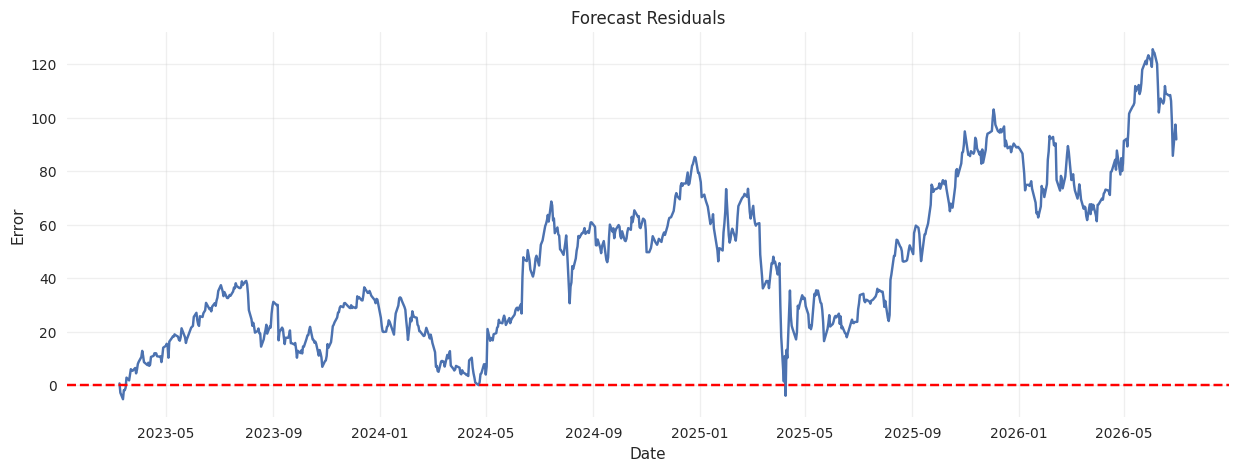

In [ ]:
# ==========================================================
# Step 14.4 : Residual Plot
# ==========================================================

errors = test - forecast

plt.figure(figsize=(15,5))

plt.plot(errors)

plt.axhline(0,color="red",linestyle="--")

plt.title("Forecast Residuals")

plt.xlabel("Date")

plt.ylabel("Error")

plt.grid(alpha=0.3)

plt.show()

## Interpretation

### MAE

Measures the average absolute forecasting error.

Lower MAE indicates better forecasting accuracy.

---

### RMSE

Penalizes larger prediction errors more heavily than MAE.

Lower RMSE indicates better model performance.

---

### MAPE

Represents the average percentage forecasting error.

Smaller values indicate more accurate predictions.

---

### Scatter Plot

If the model performs well, most points should lie close to the 45-degree reference line.

---

### Residual Plot

Residuals should fluctuate randomly around zero without showing systematic patterns.

Random residuals indicate that the model has captured most of the information present in the data.

# Final Conclusion

## Project Summary

In this project, a Seasonal AutoRegressive Integrated Moving Average (SARIMA) model was developed to forecast the next trading day's Open Price of Apple Inc. (AAPL) stock using historical data from Yahoo Finance.

The project followed a complete time series forecasting workflow including:

- Data Collection
- Data Validation
- Exploratory Data Analysis
- Stationarity Testing
- First-Order Differencing
- ACF and PACF Analysis
- SARIMA Model Training
- Residual Diagnostics
- Forecasting
- Performance Evaluation

---

## Key Findings

- The original Open Price series was non-stationary.
- First-order differencing transformed the series into a stationary process.
- Grid Search identified the optimal SARIMA parameters based on the lowest AIC.
- The SARIMA model successfully captured the long-term trend of the stock price.
- Forecast accuracy was evaluated using MAE, RMSE, and MAPE.

---

## Limitations

Although SARIMA effectively models temporal dependencies, stock prices are influenced by numerous external factors such as market sentiment, economic conditions, company announcements, and geopolitical events.

Consequently, SARIMA may struggle to capture sudden market movements and short-term volatility.

---

## Future Improvements

Potential enhancements include:

- Walk-Forward Validation
- SARIMAX with exogenous variables
- Technical Indicators (RSI, MACD, EMA, SMA)
- XGBoost
- LSTM
- Transformer-based forecasting models
- News Sentiment Analysis

---

## Final Remarks

SARIMA provides a strong statistical baseline for time series forecasting and serves as an effective learning model for understanding classical forecasting techniques.

While it may not always outperform modern machine learning or deep learning approaches for stock market prediction, it establishes a solid foundation for more advanced forecasting models.

# Project Summary

| Component | Status |
|-----------|--------|
| Data Collection | ✅ Completed |
| Data Cleaning | ✅ Completed |
| Data Validation | ✅ Completed |
| Exploratory Data Analysis | ✅ Completed |
| Stationarity Testing | ✅ Completed |
| First-Order Differencing | ✅ Completed |
| ACF & PACF Analysis | ✅ Completed |
| Grid Search | ✅ Completed |
| SARIMA Model Training | ✅ Completed |
| Residual Diagnostics | ✅ Completed |
| Forecasting | ✅ Completed |
| Performance Evaluation | ✅ Completed |
| Next-Day Prediction | ✅ Completed |

---

## Best Model

- **Model:** SARIMA
- **Order:** (0,1,2)
- **Seasonal Order:** (0,1,1,5)

---

## Performance Metrics

- MAE : _46.2528_
- RMSE : _54.5240_
- MAPE : _19.690%_

---

## Final Conclusion

The SARIMA model successfully learned the long-term temporal structure of Apple's Open Price series and produced one-step-ahead forecasts. While it captured the general trend, its ability to model short-term fluctuations was limited due to the inherently noisy and nonlinear nature of stock market data.

This project demonstrates a complete statistical time-series forecasting workflow and provides a strong baseline for future research using SARIMAX, machine learning, or deep learning approaches.